In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
diabetes = load_diabetes(as_frame=True)

df = diabetes.frame

print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [ ]:
print("\nShape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())



Shape: (442, 11)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None

Missing Values:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Summary Statistics:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
m

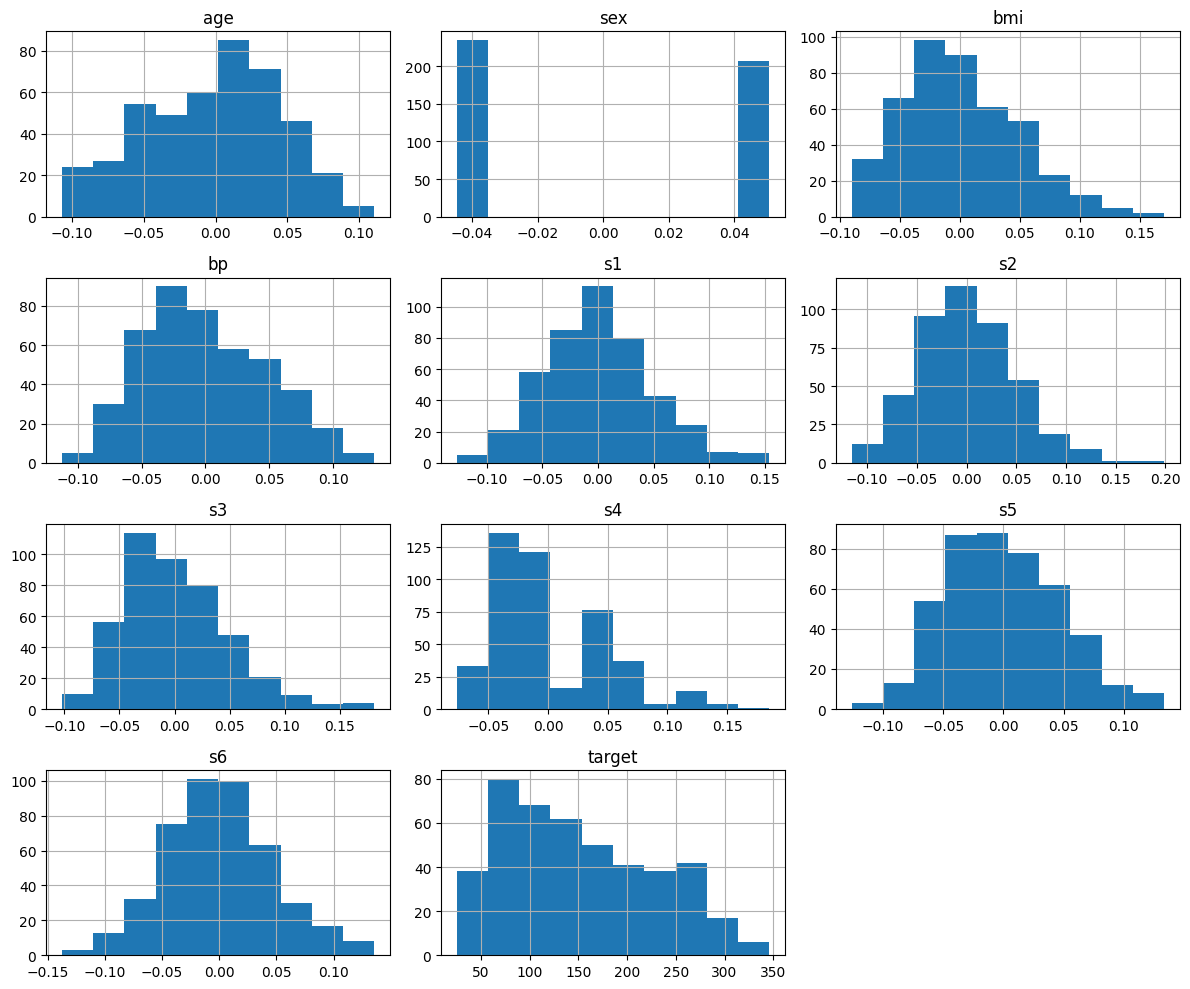

In [ ]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

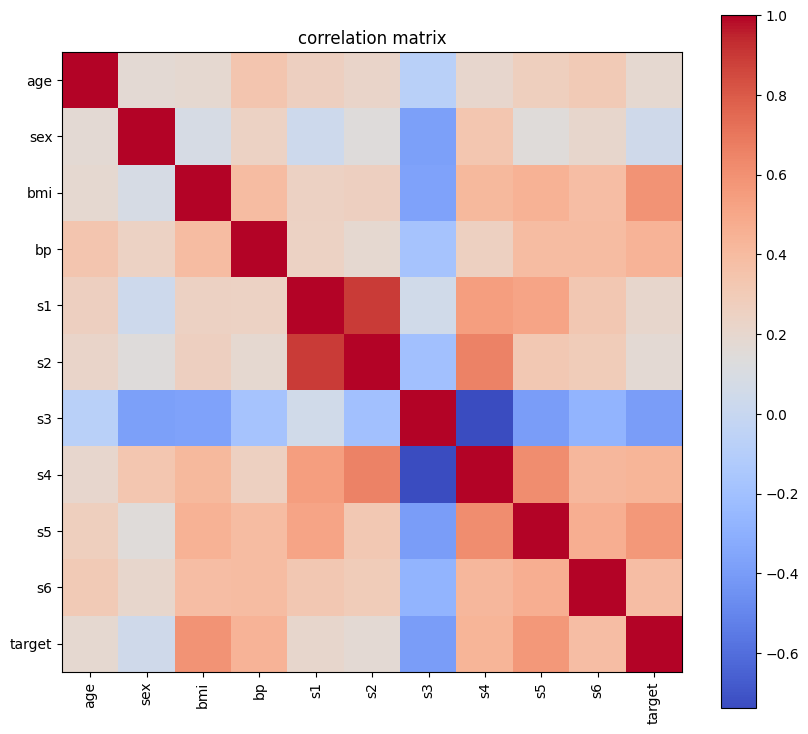

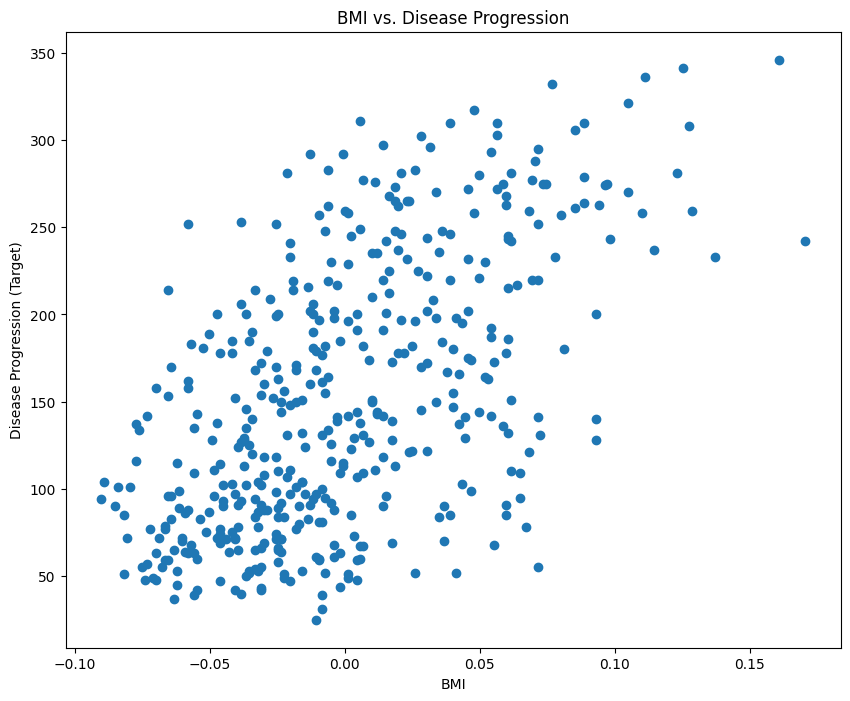

In [ ]:
corr = df.corr()
plt.figure(figsize=(10,9))
plt.imshow(corr,cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.title("correlation matrix")
plt.show()

#scatter plot
plt.figure(figsize=(10,8))
plt.scatter(df['bmi'], df['target'])
plt.xlabel("BMI")
plt.ylabel("Disease Progression (Target)")
plt.title("BMI vs. Disease Progression")
plt.show()

In [ ]:
X= df.drop('target',axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 =  r2_score(y_test,y_pred)
print("\nmodel evaluation")
print ("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print ("R2 score:",r2)


model evaluation
MAE: 42.79409467959994
MSE: 2900.1936284934814
RMSE: 53.85344583676593
R2 score: 0.4526027629719195


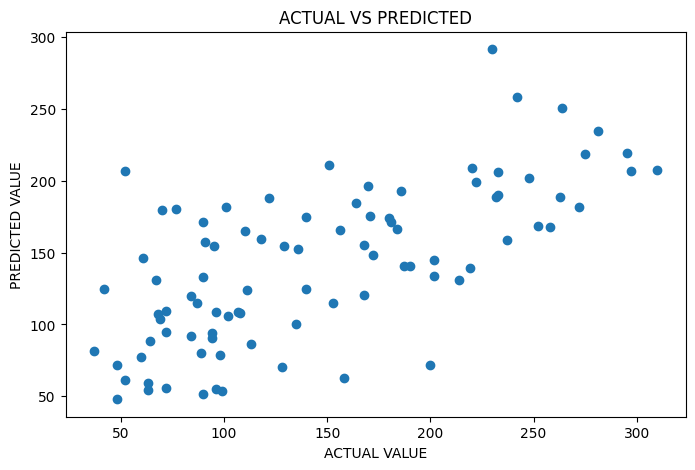

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred)
plt.xlabel("ACTUAL VALUE")
plt.ylabel("PREDICTED VALUE")
plt.title("ACTUAL VS PREDICTED")
plt.show()

In [ ]:
coef_df = pd.DataFrame({
    'features': X.columns,
    'coefficients': model.coef_
})
coef_df = coef_df.sort_values(by='coefficients', ascending = False)
print("\nFeatures coefficients:")
print(coef_df)


Features coefficients:
  features  coefficients
8       s5    736.198859
2      bmi    542.428759
5       s2    518.062277
3       bp    347.703844
7       s4    275.317902
6       s3    163.419983
9       s6     48.670657
0      age     37.904021
1      sex   -241.964362
4       s1   -931.488846
